# **LIGHTGBM - REGRESSOR**
> LightGBM is a powerful and efficient algorithm for both **Classification** and **Regression** tasks.

> Offering **high accuracy** and **fast performance** for predicting continuous values.

> Tips: Use **Cross Validation** and **Hyperparameter Tuning** for **better performance**.

### **General Recommendation:**
  - `For classification:` Start with **XGBoost** or **LightGBM**.
  - `For Classification [categorical feature and imbalanced dataset] Without Pre-processing data:` **CatBoost** 
  - `For regression:` **LightGBM** or **XGBoost** is highly recommended.

<br>

---

<br>

## 1. What is LightGBM?
- **LightGBM** (Light Gradient Boosting Machine) is a distributed, high-performance gradient boosting framework.
- It is optimized for speed, efficiency, and scalability.
- Commonly used for supervised learning tasks like classification and regression.

<br>

---

<br>

## 2. Key Features
- **Boosting Framework**: Builds trees sequentially to minimize the error of the previous trees.
- **Histogram-based Algorithm**: Uses a histogram for faster computation and lower memory usage.
- **Regularization**: Prevents overfitting using L1 and L2 penalties.
- **Tree-based Model**: Uses decision trees as base learners.
- **Parallel Processing**: Supports faster computation using multiple cores.
- **Cross-Platform Support**: Compatible with Python, R, C++, and other languages.

<br>

---

<br>

<h2>3. Comparison of <strong>Regression Objectives</strong> in LightGBM</h2>

<table style="width:100%; border-collapse: collapse; font-family: Arial, sans-serif;">
  <thead>
    <tr>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Objective</th>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Use Case</th>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Output</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><strong>regression</strong></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Standard regression with MSE loss</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Predicted continuous values</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><strong>huber</strong></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Huber loss function for regression</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Predicted continuous values</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><strong>fair</strong></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Fair regression loss function</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Predicted continuous values</td>
    </tr>
  </tbody>
</table>

<br>

---

<br>

## 4. Advantages
- **Handles Missing Values**: Automatically learns best splits for missing values.
- **Feature Importance**: Provides insights into feature contribution.
- **Scalability**: Performs well on large datasets.
- **Regularization**: Reduces the risk of overfitting.

<br>

---

<br>

## ⭐ Things to Keep in Mind
- Ensure compatible versions of **LightGBM** and **scikit-learn**.
- **Hyperparameter tuning** is essential for **optimal performance**.
- Watch out for **overfitting** on small datasets; **use cross-validation**.

<br>

---


In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings

In [2]:
# Ignore FutureWarnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
df = pd.read_csv('/content/61_laptop_prices_data.csv')

In [4]:
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [5]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='object')

In [6]:
df.shape

(1275, 23)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

In [8]:
df.describe()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


In [9]:
le = LabelEncoder()
df['Company'] = le.fit_transform(df['Company'])
df['Product'] = le.fit_transform(df['Product'])
df['TypeName'] = le.fit_transform(df['TypeName'])
df['OS'] = le.fit_transform(df['OS'])
df['Screen'] = le.fit_transform(df['Screen'])
df['Touchscreen'] = le.fit_transform(df['Touchscreen'])
df['IPSpanel'] = le.fit_transform(df['IPSpanel'])
df['RetinaDisplay'] = le.fit_transform(df['RetinaDisplay'])
df['CPU_company'] = le.fit_transform(df['CPU_company'])
df['CPU_model'] = le.fit_transform(df['CPU_model'])
df['PrimaryStorage'] = le.fit_transform(df['PrimaryStorage'])
df['SecondaryStorageType'] = le.fit_transform(df['SecondaryStorageType'])
df['PrimaryStorageType'] = le.fit_transform(df['PrimaryStorageType'])
df['GPU_company'] = le.fit_transform(df['GPU_company'])
df['GPU_model'] = le.fit_transform(df['GPU_model'])

In [10]:
X = df.drop(["Price_euros", "Product"], axis = 1)
Y = df['Price_euros']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size = 0.2)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# !pip install dask[dataframe]

In [14]:
# import lightgbm
import lightgbm as lgb

> Hyperparameters for LightGBM Regressor

```python
model = lgb.LGBMRegressor(
    # Model Hyperparameters
    objective='regression',          # Objective function for regression
    n_estimators=100,                # Number of boosting rounds (trees)
    max_depth=-1,                    # Maximum depth of each tree (-1 means no limit)
    learning_rate=0.1,               # Step size at each iteration
    subsample=1.0,                   # Fraction of samples used for each tree to prevent overfitting
    colsample_bytree=1.0,            # Fraction of features used for each tree to prevent overfitting
    
    # Regularization Parameters (optional)
    reg_alpha=0,                     # L1 regularization term on weights (Lasso)
    reg_lambda=0,                    # L2 regularization term on weights (Ridge)
    
    # Tree Growth Parameters
    min_child_weight=1,              # Minimum number of samples required in a child node to split further
)
```

<h3>Comparison of <strong>Regression Objectives</strong> in LightGBM</h3>

<table style="width:100%; border-collapse: collapse; font-family: Arial, sans-serif;">
  <thead>
    <tr>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Objective</th>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Use Case</th>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Output</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><strong>regression</strong></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Standard regression with MSE loss</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Predicted continuous values</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><strong>huber</strong></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Huber loss function for regression</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Predicted continuous values</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><strong>fair</strong></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Fair regression loss function</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Predicted continuous values</td>
    </tr>
  </tbody>
</table>

In [15]:
# Initialize the LightBGM Regressor
model = lgb.LGBMRegressor(objective='regression', random_state=42)

In [16]:
# Train the dataset with LightBGM Model
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000305 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 378
[LightGBM] [Info] Number of data points in the train set: 1020, number of used features: 20
[LightGBM] [Info] Start training from score 1145.043147


LGBMRegressor(objective='regression', random_state=42)

In [17]:
# Make predictions
y_pred = model.predict(X_test)

In [18]:
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [19]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error: 63774.88
R2 Score: 0.86


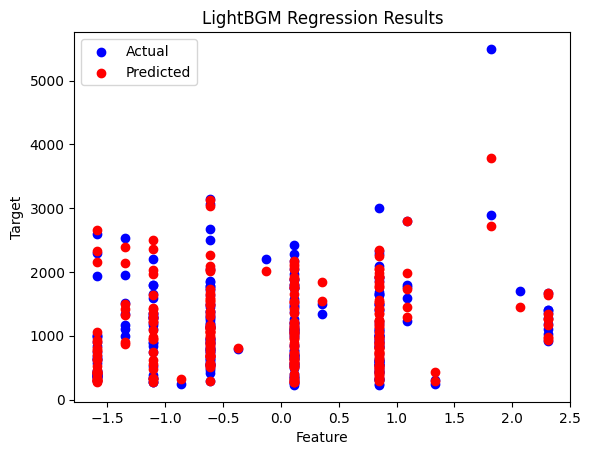

In [20]:
# Plot Result
import matplotlib.pyplot as plt

# Assuming X_test has multiple features, we'll plot against the first feature
plt.scatter(X_test[:, 0], y_test, color='blue', label='Actual')
plt.scatter(X_test[:, 0], y_pred, color='red', label='Predicted')
plt.legend()
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('LightBGM Regression Results')
plt.show()